# Demonstrating `uncertainty` module

In this notebook we show the how to use and apply the classess and method in the sub modules of the `uncertainty` module this include:
- Importing uncertainty information
- Filtering uncertain parameters
- selecting and changing probability distribution information of uncertain parameters

In [69]:
%load_ext autoreload
%autoreload 2
import os
import sys
import pandas as pd
import numpy as np
sys.path.append('..')
from pulpo import pulpo
from pulpo.utils.uncertainty import preparer, processor, plots, gsa
from pulpo.utils import optimizer, saver

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Defining the underlying case study

In [4]:
from typing import Union, List, Optional, Dict, Tuple

class BaseCaseStudy:
    """
    Abstract base class for a PULPO‐based LCA case study.

    Attributes:
        project (str): PULPO project name.
        database (str or list of str): Name(s) of the inventory database.
        method (str, list, or dict): LCIA method specification.
        directory (str): Working directory for inputs/outputs.
        pulpo_worker (pulpo.PulpoOptimizer): Solver instance, created by create_pulpo_worker.
        demand (dict): Functional unit demands (process → amount).
        choices (dict): Choices (process → capacity) in the model.
    """

    def __init__(self, project:str, database: Union[str, List[str]], method:Union[str, List[str], dict], directory :str ):
        """
        Initialize the case study with project, database, method, and directory.

        Args:
            project: Name of the PULPO project.
            database: Inventory database(s) to load.
            method: LCIA method(s) to apply.
            directory: Path to working directory for saving results.
        """
        self.project = project
        self.database = database
        self.method = method
        self.directory = directory
        self.demand:dict = {}
        self.choices:dict = {}

    def create_pulpo_worker(self):
        """
        Instantiate a PulpoOptimizer and import LCI data.

        Creates `self.pulpo_worker` and calls its get_lci_data() to load
        life cycle inventory matrices and metadata.
        """
        # Create a **PulpoOptimizer** instance. This class is used to interact with the LCI database and solve the optimization problem. It is specified by the project, database, method and directory.
        self.pulpo_worker = pulpo.PulpoOptimizer(self.project, self.database, self.method, self.directory)
        # Import LCI data. After initializing the PulpoOptimizer instance, the LCI data is imported from the database.
        self.pulpo_worker.get_lci_data()

    def solve_and_summarize(self, file_name) -> dict:
        """
        Solve the optimization model and summarize results.

        Args:
            file_name: Filename for saving results (ignored if saver used directly).

        Returns:
            result_data (dict): Extracted results dictionary.
        """

        # Instantiat and solve the optimization model
        # self.pulpo_worker.solve()
        # options = {'NEOS_EMAIL':'b.j.p.m.haussling.lowgren@cml.leidenuniv.nl'}
        # self.pulpo_worker.solve(solver_name='cplex', options=options)
        self.pulpo_worker.solve()
        # Save and summarize the results
        result_data = self.pulpo_worker.extract_results()
        self.pulpo_worker.summarize_results(zeroes=True)
        # self.pulpo_worker.save_results(result_data, file_name) # ATTN: This still does not work with the saver code probably still a mistake in there
        return result_data
    
class AmmoniaCase(BaseCaseStudy):
    """
    Case study for the reducts Ammonia case study.

    Defines the functional unit, choice sets, and instantiates the PULPO model.
    """
    def __init__(self):
        """
        Set up default project, database, method, and directory
        for the Ammonia case study.
        """
        self.project = "ammonia_reduced"
        self.database = ["ecoinvent-3.10-cutoff", "ammonia-reduced"]
        self.method = "('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')"
        self.directory = os.path.join(os.path.dirname(os.getcwd()), 'develop_tests/data')

    def create_pulpo_worker(self):
        """
        Instantiate a PulpoOptimizer and import LCI data.

        Creates `self.pulpo_worker` and calls its get_lci_data() to load
        life cycle inventory matrices and metadata.
        """
        # Create a **PulpoOptimizer** instance. This class is used to interact with the LCI database and solve the optimization problem. It is specified by the project, database, method and directory.
        self.pulpo_worker = pulpo.PulpoOptimizer(self.project, self.database, self.method, self.directory)
        self.pulpo_worker.intervention_matrix="ecoinvent-3.10-biosphere"
        # Import LCI data. After initializing the PulpoOptimizer instance, the LCI data is imported from the database.
        self.pulpo_worker.get_lci_data()

    def define_problem(self):
        """
        Specify the functional unit, define choice options and capacities,
        and instantiate the PULPO model with self.pulpo_worker.instantiate().
        """
        
        choices_biomethane_CS = ["biogas upgrading to biomethane, chemical scrubbing"]
        choices_biomethane_CSwCCS = ["biogas upgrading to biomethane, chemical scrubbing w/ CCS"]
        choices_biomethane_WS = ["biogas upgrading to biomethane, water scrubbing"]
        choices_biomethane_WSwCCS = ["biogas upgrading to biomethane, water scrubbing w/ CCS"]

        choices_methane_market = [
            "market for bio methane",
            "market group for natural gas, high pressure"
        ]

        choices_hydrogen_SMR = ["hydrogen production, steam methane reforming fg"]
        choices_hydrogen_SMRwCCS = ["hydrogen production, steam methane reforming, w/ CCS"]
        choices_hydrogen_PEM = ["hydrogen production, PEM electrolysis, yellow"]
        choices_hydrogen_plastic = ["hydrogen production, plastics gasification"]
        choices_hydrogen_plasticCCS = ["hydrogen production, plastics gasification, w/ CCS"]

        choices_hydrogen_market = [
            "market for hydrogen",
            "market for hydrogen, gaseous, low pressure"
        ]

        choices_heat_H2 = ["heat from hydrogen"]
        choices_heat_CH4wCCS = ["heat from methane, w/ CCS"]
        choices_heat_CH4 = ["heat from methane"]

        choices_ammonia = [
            "ammonia production, steam methane reforming",
            # "ammonia production, steam methane reforming, w/ CCS",
            "ammonia production, from nitrogen and hydrogen"
        ]

        choices_ammonia_market = [
            "market for ammonia",
            "market for ammonia, anhydrous, liquid"
        ]

        # Retrieve activities for each category and assign to appropriately named variables
        # Retrieve activities for each category and assign to appropriately named variables
        # Biomethane upgrading
        biomethane_activities_CS = self.pulpo_worker.retrieve_activities(activities=choices_biomethane_CS, locations=["RER", "Europe without Switzerland"])
        biomethane_activities_CSwCCS = self.pulpo_worker.retrieve_activities(activities=choices_biomethane_CSwCCS, locations=["RER", "Europe without Switzerland"])
        biomethane_activities_WS = self.pulpo_worker.retrieve_activities(activities=choices_biomethane_WS, locations=["RER", "Europe without Switzerland"])
        biomethane_activities_WSwCCS = self.pulpo_worker.retrieve_activities(activities=choices_biomethane_WSwCCS, locations=["RER", "Europe without Switzerland"])

        methane_market_activities = self.pulpo_worker.retrieve_activities(activities=choices_methane_market, locations=["RER", "Europe without Switzerland"])
        # Hydrogen
        hydrogen_activities_PEM = self.pulpo_worker.retrieve_activities(activities=choices_hydrogen_PEM, locations=["RER", "Europe without Switzerland"])
        hydrogen_activities_plastic = self.pulpo_worker.retrieve_activities(activities=choices_hydrogen_plastic, locations=["RER", "Europe without Switzerland"])
        hydrogen_activities_plasticCCS = self.pulpo_worker.retrieve_activities(activities=choices_hydrogen_plasticCCS, locations=["RER", "Europe without Switzerland"])
        hydrogen_activities_SMR = self.pulpo_worker.retrieve_activities(activities=choices_hydrogen_SMR, locations=["RER", "Europe without Switzerland"])
        hydrogen_activities_SMRwCCS = self.pulpo_worker.retrieve_activities(activities=choices_hydrogen_SMRwCCS, locations=["RER", "Europe without Switzerland"])
        hydrogen_market_activities = self.pulpo_worker.retrieve_activities(activities=choices_hydrogen_market, locations=["RER", "Europe without Switzerland"])
        # Heat
        heat_activities_CH4 = self.pulpo_worker.retrieve_activities(activities=choices_heat_CH4, locations=["RER", "Europe without Switzerland"])
        heat_activities_CH4wCCS = self.pulpo_worker.retrieve_activities(activities=choices_heat_CH4wCCS, locations=["RER", "Europe without Switzerland"])
        heat_activities_H2 = self.pulpo_worker.retrieve_activities(activities=choices_heat_H2, locations=["RER", "Europe without Switzerland"])
        # Ammonia
        ammonia_activities = self.pulpo_worker.retrieve_activities(activities=choices_ammonia, locations=["RER", "Europe without Switzerland"])
        ammonia_market_activities = self.pulpo_worker.retrieve_activities(activities=choices_ammonia_market, locations=["RER", "Europe without Switzerland"])
        
        # Set the demand and other global parameters for the problem definition
        demand_value = 3000e6 
        manure_biogas = 1.8e9 # Setting the manure biomgas availability for 2030
        scale_by_demand = False
        if scale_by_demand:
            scaling_value = demand_value
        else:
            scaling_value = 1

        # Choices as constraints
        self.choices = {
            "ammonia": {x: 1e20 for x in ammonia_activities},
            "methane_market": {x: 1e20 for x in methane_market_activities},
            "hydrogen_market": {x: 1e20 for x in hydrogen_market_activities},
            "ammonia_market": {x: 1e20 for x in ammonia_market_activities},
        }
        self.choices["hydrogen"] = {
            hydrogen_activities_PEM[0] : .3*.1e9/scaling_value, # 0.1 Mt H2 -- 30% of PEM to NH3
            hydrogen_activities_SMR[0] : 1e20, # SMR
            hydrogen_activities_SMRwCCS[0] : .3*.5e9/scaling_value, # 0.5 Mt H2 -- 30% of SMR w CCS H2 for NH3
            hydrogen_activities_plastic[0] : .3*40e6/scaling_value, # 40 kt H2 -- 30% of plastic gasification for NH3
            hydrogen_activities_plasticCCS[0] : .3*1e6/scaling_value, # 10 kt H2 -- 30% of plastic gasification w CCS for NH3
        }
        self.choices["heat"] = {
            heat_activities_CH4[0]: 1e20,
            heat_activities_CH4wCCS[0]: .1*1.4e10/scaling_value, # Assuming 10% of the heat currently needed for Ammonia produciton
            heat_activities_H2[0]:1*1.4e10/scaling_value, # Assuming 10% of the heat currently needed for Ammonia produciton
        }
        self.choices["biomethane"] = {
            biomethane_activities_CS[0]: 1e20, # Assumingly the same potential as WS
            biomethane_activities_CSwCCS[0]: .1*.2*manure_biogas/scaling_value, # Guess: the same as WS wCCS
            biomethane_activities_WS[0]: 1e20, # Assumingly the base case technology
            biomethane_activities_WSwCCS[0]: .1*.2*manure_biogas/scaling_value #  20% (biomethane for NH3) of 10% (CCS for biomethane )of 1.8 mt (biomethane) for which is the max capacity 2030
        }
        
        # Additional constraints
        anaerobic_digestion = self.pulpo_worker.retrieve_activities(activities='anaerobic digestion of animal manure, with biogenic carbon uptake', locations=["RER", "Europe without Switzerland"])
        upper_bound = {
            anaerobic_digestion[0]:.2*1.8e9/scaling_value # 20% of 1.8 mt which is the max capacity 2030
            } 

        # Demand
        ammonia_market = self.pulpo_worker.retrieve_activities(activities="market for ammonia")
        self.demand = {"ammonia_market": demand_value/scaling_value} # Ammonia production capacity Germany
        
        # Instantiate the pulpo instance
        self.pulpo_worker.instantiate(choices=self.choices, demand=self.demand, upper_limit=upper_bound)



In [5]:
case_study = AmmoniaCase()
case_study.create_pulpo_worker()
case_study.define_problem()
result_data = case_study.solve_and_summarize(file_name='ammonia_test')


Creating Instance
Instance created
Running HiGHS 1.8.0 (git hash: eda5cbe): Copyright (c) 2024 HiGHS under MIT licence terms
Cols:       47102 lower bounds    less than or equal to       -1e+20 are treated as -Infinity
Cols:       47102 upper bounds greater than or equal to        1e+20 are treated as +Infinity
Rows:       23537 lower bounds    less than or equal to       -1e+20 are treated as -Infinity
Rows:       23549 upper bounds greater than or equal to        1e+20 are treated as +Infinity
optimal solution found:  3881518178.900435


## Total Impact(s)

,Weight,Value
Method,,
"('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')",1,3.881518e+09


## Choices Made

### ammonia

...

### biomethane

,Value,Capacity
Metadata,,
"biogas upgrading to biomethane, chemical scrubbing | biomethane, 24 bar | RER",1.351234e+08,1.000000e+20
"biogas upgrading to biomethane, chemical scrubbing w/ CCS | biomethane, 24 bar | RER",3.600000e+07,3.600000e+07
"biogas upgrading to biomethane, water scrubbing w/ CCS | biomethane, 24 bar | RER",3.600000e+07,3.600000e+07


## Constraints

### Constraints Upper

,Key,Metadata,Value,Limit
ID,,,,
23532,"(ammonia-reduced, a2610a42cd93afb46b13b2e95273...","anaerobic digestion of animal manure, with bio...",360000000.0,360000000.0


## 2. Filtering out negletable uncertain parameters

We only consider uncertainty in the $B$ and $Q$ parameter matrizes. The scaling vector is given by the optimal solution.

The parameter filter, aims to reduce the set of uncertain parameters to reduce the computational effort for the GSA or for CC optimization. 

There is however an inherent risk when reducing the set of parameters before using chance constraint optimization, since relevant uncertain parameters at the non deterministic solution might be filtered out, which can be significant at higher probability levels.

In [17]:
paramfilter = preparer.ParameterFilter(
    lci_data=case_study.pulpo_worker.lci_data, 
    choices = case_study.choices,
    demand = case_study.demand,
    method = case_study.method
    )

Using the basic scaling vector which only includes the optimal choices in the scaling vector

In [18]:
scaling_vector_series = paramfilter.prepare_scaling_vector(scaling_vector_strategy='naive', result_data=result_data)

Using the scaling vector constructed from all choices

In [19]:
scaling_vector_series = paramfilter.prepare_scaling_vector(scaling_vector_strategy='constructed_demand')

Compute the LCA scores and return the characterized inventory to be used for the filtering

In [20]:
lca_score, characterized_inventory = paramfilter.compute_LCI_LCIA(scaling_vector_series)

chosen environmental impact method: ('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')
The total impact is: 5.426719e+01


Plot the largest contributors

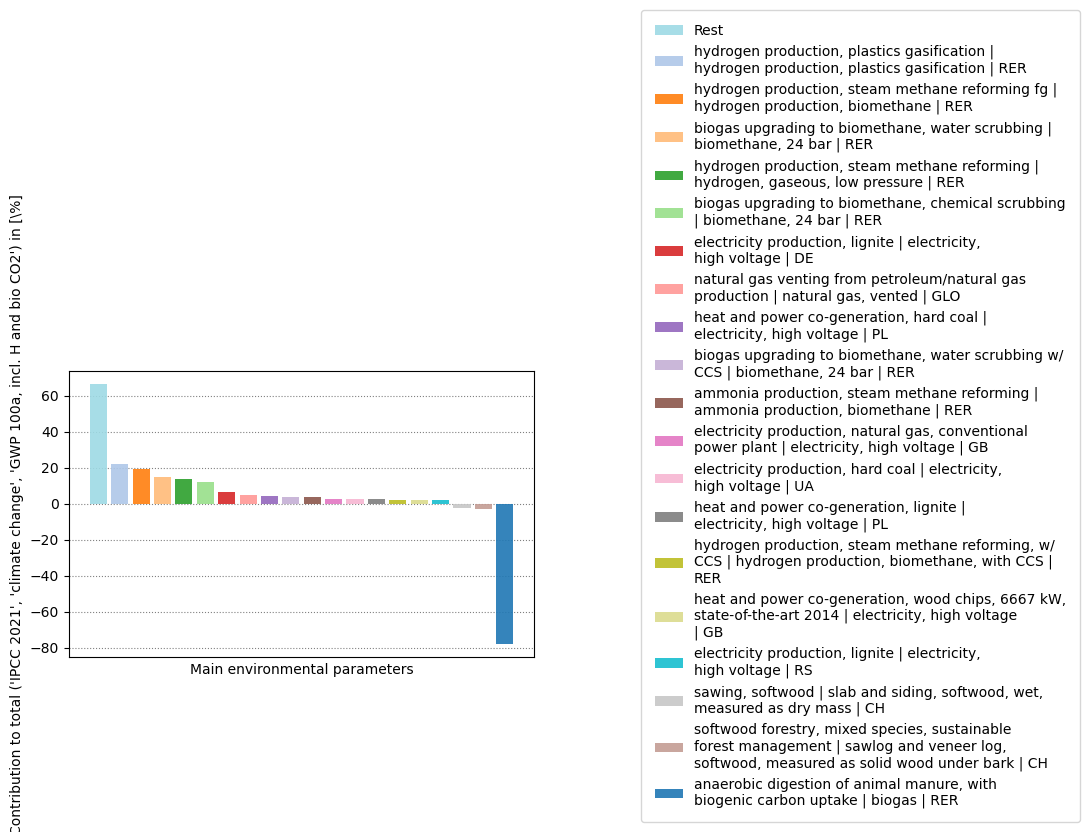

In [21]:
plots.plot_top_characterized_processes(case_study.pulpo_worker.lci_data['process_map_metadata'], characterized_inventory, case_study.method, top_amount=19)

Filtering out the inventoryflows $B_{i,j}$ that have a neglectable impact

In [22]:
cutoff = 0.000019 # ATTN: Change to 0. to include all parameters, this is needed to include the CCS biosphere flows else they are filtered out
# cutoff = 0.
filtered_inventory_indcs = paramfilter.filter_inventoryflows(characterized_inventory, lca_score, cutoff)

Characterized inventory: (2648, 23557) 26581
Filtered characterized inventory: (2648, 23557) 1009
Deviation from LCA score: 0.009507277234347966
inventory (2648, 23557) filtering resulted in 1009 of 26581 exchanges (99.05% of total impact) and took 0.014 seconds.


In [23]:
filtered_characterization_indcs = paramfilter.filter_characterization_factors(filtered_inventory_indcs)

CHARACTERIZATION MATRIX (2648,) filtering resulted in 27 of 111 characterization factors


Alternativly all the methods can be called with the `apply_filter` method.

chosen environmental impact method: ('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')
The total impact is: 5.426719e+01


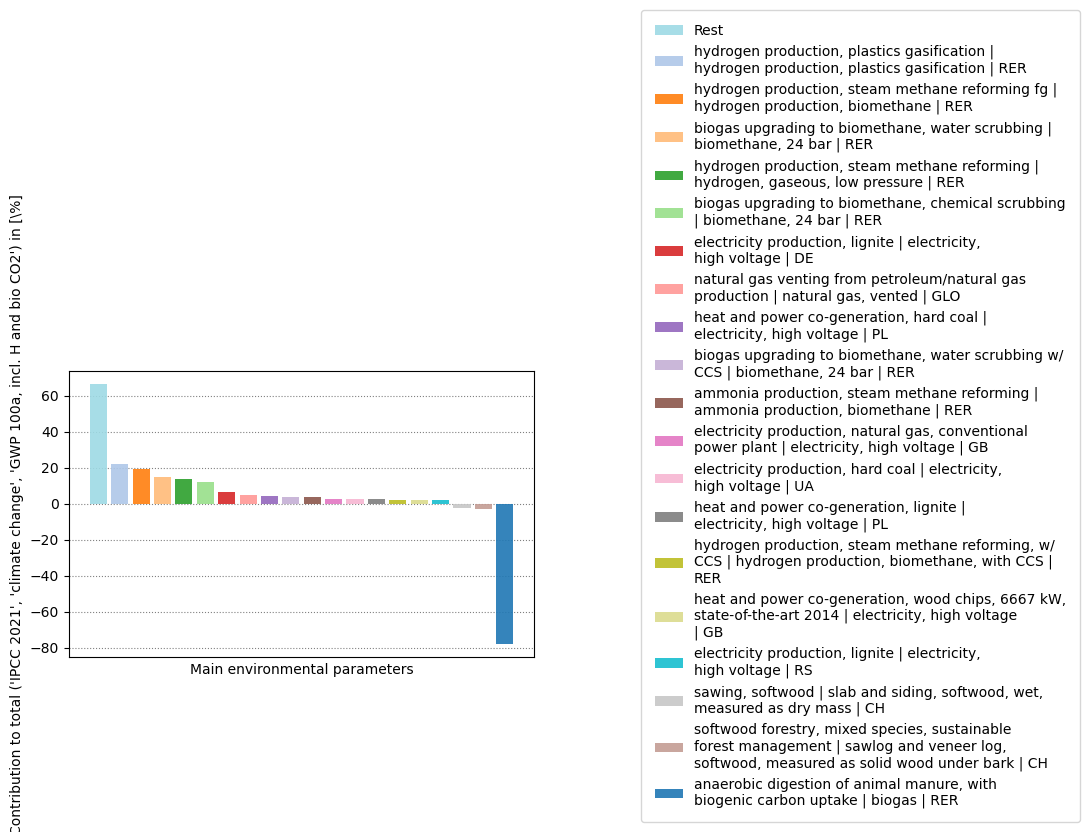

Characterized inventory: (2648, 23557) 26581
Filtered characterized inventory: (2648, 23557) 177
Deviation from LCA score: 0.12532326402220306
inventory (2648, 23557) filtering resulted in 177 of 26581 exchanges (87.47% of total impact) and took 0.003 seconds.
CHARACTERIZATION MATRIX (2648,) filtering resulted in 11 of 111 characterization factors


In [24]:
filtered_inventory_indcs, filtered_characterization_indcs = paramfilter.apply_filter(
    scaling_vector_strategy='constructed_demand',
    cutoff=0.001,
    plot_results=True,
    plot_n_top_processes=19
)

## 3. Getting the uncertainty of the parameter values

The uncertainty data can be filtered and imported and strategies applied directly with the pulpo worker, shown below. In the following subsections the method called in the pulpo worker wrapper methods are shown and explained

chosen environmental impact method: ('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')
The total impact is: 5.426719e+01


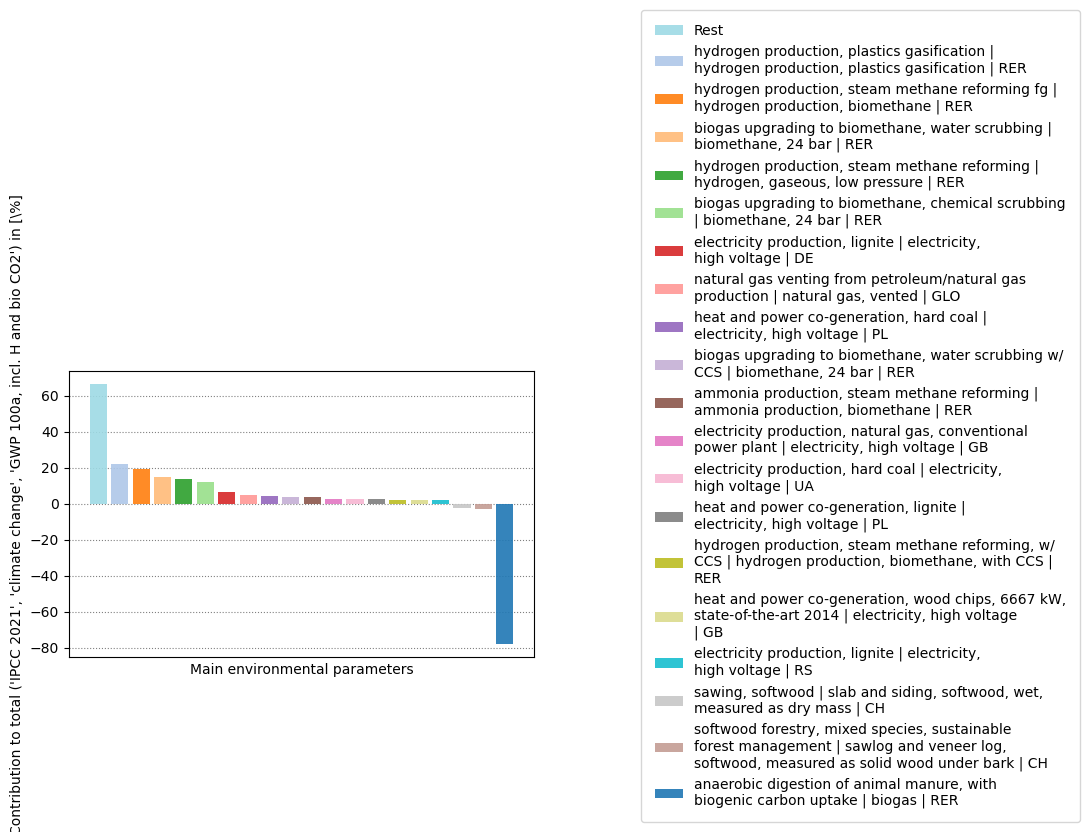

Characterized inventory: (2648, 23557) 26581
Filtered characterized inventory: (2648, 23557) 1009
Deviation from LCA score: 0.009507277234347966
inventory (2648, 23557) filtering resulted in 1009 of 26581 exchanges (99.05% of total impact) and took 0.004 seconds.
CHARACTERIZATION MATRIX (2648,) filtering resulted in 27 of 111 characterization factors
Intervention flows:
In ecoinvent-3.10-cutoff:
Parameters with uncertainty information: 886 
Parameters without uncertainty information: 96
In ammonia-reduced:
Parameters with uncertainty information: 0 
Parameters without uncertainty information: 27
Charactetization factors:
Parameters with uncertainty information: 0 
Parameters without uncertainty information: 27
Variable bounds:
Upper bound from choices without uncertainty information: 20
Upper bound from `upper_limit` without uncertainty information: 1
Lower bound from `lower_limit` without uncertainty information: 0


In [7]:
case_study.pulpo_worker.import_and_filter_uncertainty_data(
    cutoff=0.000019,
    scaling_vector_strategy='constructed_demand',
    plot_results=True,
    plot_n_top_processes=19
)

### 3.1. Importing the uncertainty data

Imports uncertainty data for the intervention flows and the characterization factors from the databases and Brightway project. It also creates uncertainty data (with unspecified distributions) for the variables bounds specified for the pulpo instance.

Extracts the metadata containing the uncertainty information to the filtered intervention flows and seperate the metadata into the parameters with and without defined uncertainty information

In [25]:
uncertainty_importer = preparer.UncertaintyImporter(
    lci_data=case_study.pulpo_worker.lci_data, 
    bw_databases=case_study.database, 
    LCIA_method=case_study.method,
)
uncertainty_data = uncertainty_importer.import_uncertainty_data(
    if_indcs=filtered_inventory_indcs,
    cf_indcs=filtered_characterization_indcs,
    choices=case_study.pulpo_worker.choices,
    upper_limit=case_study.pulpo_worker.upper_limit,
    lower_limit=case_study.pulpo_worker.lower_limit,
    upper_elem_limit=case_study.pulpo_worker.upper_elem_limit,
    upper_imp_limit=case_study.pulpo_worker.upper_imp_limit,
)

Intervention flows:
In ecoinvent-3.10-cutoff:
Parameters with uncertainty information: 134 
Parameters without uncertainty information: 25
In ammonia-reduced:
Parameters with uncertainty information: 0 
Parameters without uncertainty information: 18
Charactetization factors:
Parameters with uncertainty information: 0 
Parameters without uncertainty information: 11
Variable bounds:
Upper bound from choices without uncertainty information: 20
Upper bound from `upper_limit` without uncertainty information: 1
Lower bound from `lower_limit` without uncertainty information: 0


### 3.2. Apply strategies to define missing uncertainty data

#### 3.2.1. Intervention flows

In [26]:
print(case_study.database)

['ecoinvent-3.10-cutoff', 'ammonia-reduced']


Apply the triangular strategy using bound interpolation to the missing intervention uncertainty parameters in the background database

In [27]:
if_bg_triangular_strategy = processor.TriangularBoundInterpolationStrategy(
    uncertain_param_type='If',
    uncertain_param_subgroup='ecoinvent-3.10-cutoff',
    noise_interval={'min':.1, 'max':.1}
    )
if_bg_triangular_strategy.assign(uncertainty_data)

upper spread statistics
mean: 0.5762
mode: 0    0.438093
dtype: float64
median: 0.4918
std: 0.7305
min: 0.0582
max: 4.0573


lower spread statistics
mean: 0.3080
mode: 0    0.304635
dtype: float64
median: 0.3297
std: 0.1422
min: 0.0550
max: 0.8023

The upper spread scaling factor for intervention flows is: 0.49182484911329366
The lower spread scaling factor for intervention flows is: 0.32967994411934776


Apply the Uniform strategy for the uncertainty parameters in the foreground database

In [28]:
if_fg_uniform_strategy = processor.UniformBaseStrategy(
    uncertain_param_type='If',
    uncertain_param_subgroup='ammonia-reduced',
    upper_scaling_factor = .5,
    lower_scaling_factor = .5,
    noise_interval={'min':.2, 'max':.2}
)
if_fg_uniform_strategy.assign(uncertainty_data)

Set expert judgement uncertainties to a few selected intervention flows:

In [29]:
# ATTN: It might be better to not call an index directly but search for the process and the intervention flow, just not sure how
# This can be done in a step before which returns the indices and can be called like defined here
CCS_expert_uncertainty_info = {
    (80, 23548): {'minimum':.01 ,'maximum':.5, 'uncertainty_type':4}, # carbon dioxide storage and transport 200 km pipeline, storage 1000 m | carbon dioxide storage and transport 200 km pipeline, storage 1000 m | RER --- Carbon dioxide, fossil | ('air', 'urban air close to ground')
    (80, 23538): {'minimum':.0002 ,'maximum':.002, 'uncertainty_type':4}, # transport, pipeline, supercritical carbon dioxide, 200 km without recompression | transport, pipeline, supercritical carbon dioxide, 200 km without recompression | RER --- Carbon dioxide, fossil | ('air', 'urban air close to ground')
    }
if_fg_expert_knowledge_strategy = processor.ExpertKnowledgeStrategy(
    uncertain_param_type='If',
    uncertain_param_subgroup='ammonia-reduced',
    prob_metadata=CCS_expert_uncertainty_info
)
if_fg_expert_knowledge_strategy.assign(uncertainty_data)

Exception: (80, 23538) is not found in "defined" uncertainty data of ammonia-reduced in If.

Check if the uncertainty data has been assgined correctly to the flows

In [ ]:
processor.rename_metadata_index(
    pd.DataFrame.from_records(uncertainty_data['If']['ammonia-reduced']['defined'])[list(CCS_expert_uncertainty_info.keys())].T, 
    case_study.pulpo_worker.lci_data, 
    'intervention_flow'
    )


#### 3.2.2. Characterization factors

Apply the triangular strategy using predefined scaling factors to the missing uncertainty parameters

In [30]:
cf_triangular_strategy = processor.TriangluarBaseStrategy(
    uncertain_param_type='Cf',
    uncertain_param_subgroup=case_study.method,
    upper_scaling_factor = 0.15,
    lower_scaling_factor = 0.15,
    noise_interval={'min':.1, 'max':.1}
)
cf_triangular_strategy.assign(uncertainty_data)

#### 3.2.3. Variable bounds

Defining the uncertainty information for the variable bounds

Apply triangular uncertainty strategy with upper and lower scaling factor to the variable bounds (any other strategy is also possible)

In [31]:
var_bound_upper_strategy = processor.TriangluarBaseStrategy(
    uncertain_param_type='Var_bounds',
    uncertain_param_subgroup='upper_limit',
    upper_scaling_factor=.3,
    lower_scaling_factor=.3,
    noise_interval={'min':.2, 'max':.1}
)
var_bound_upper_strategy.assign(uncertainty_data)

#### 3.2.4. All at once

The strategies can all be applied at once if they are passed to the `apply_uncertainty_strategies` method.

In the future this can also easily be rewritten to pass a json file or dict containing the set up for each uncertainty strategy

In [ ]:
processor.apply_uncertainty_strategies(
    uncertainty_data,
    processor.TriangularBoundInterpolationStrategy(
        uncertain_param_type='If',
        uncertain_param_subgroup='ecoinvent-3.10-cutoff',
        noise_interval={'min':.1, 'max':.1}
    ),
    processor.UniformBaseStrategy(
        uncertain_param_type='If',
        uncertain_param_subgroup='ammonia-reduced',
        upper_scaling_factor = .5,
        lower_scaling_factor = .5,
        noise_interval={'min':.2, 'max':.2}
    ),
    processor.ExpertKnowledgeStrategy(
        uncertain_param_type='If',
        uncertain_param_subgroup='ammonia-reduced',
        prob_metadata={
            (80, 23548): {'minimum':.01 ,'maximum':.5, 'uncertainty_type':4}, # carbon dioxide storage and transport 200 km pipeline, storage 1000 m | carbon dioxide storage and transport 200 km pipeline, storage 1000 m | RER --- Carbon dioxide, fossil | ('air', 'urban air close to ground')
            (80, 23538): {'minimum':.0002 ,'maximum':.002, 'uncertainty_type':4}, # transport, pipeline, supercritical carbon dioxide, 200 km without recompression | transport, pipeline, supercritical carbon dioxide, 200 km without recompression | RER --- Carbon dioxide, fossil | ('air', 'urban air close to ground')
        }
    ),
    processor.TriangluarBaseStrategy(
        uncertain_param_type='Cf',
        uncertain_param_subgroup=case_study.method,
        upper_scaling_factor = 0.15,
        lower_scaling_factor = 0.15,
        noise_interval={'min':.1, 'max':.1}
    ),
    processor.TriangluarBaseStrategy(
        uncertain_param_type='Var_bounds',
        uncertain_param_subgroup='upper_limit',
        upper_scaling_factor=.3,
        lower_scaling_factor=.3,
        noise_interval={'min':.2, 'max':.1}
    )
)

The uncertainty strategies can be directly performed on the pulpo worker if the strategies are passed to the pulpo worker, else a standard trigional distribution is used

In [37]:
case_study.pulpo_worker.apply_uncertainty_strategies()

Applying default uncertainty strategies.
Creating base case uncertainty strategies for intervention flows
	Creating triangular bound interpolation strategy for intervention flows in database: ecoinvent-3.10-cutoff
	Creating triangular bound interpolation strategy for intervention flows in database: ammonia-reduced
Creating triangular bound base strategy for Characterization factors: (
Creating triangular bound base strategy for variable bounds
Applying uncertainy strategy TriangularBoundInterpolationStrategy, for ecoinvent-3.10-cutoff in If
upper spread statistics
mean: 0.9149
mode: 0    3.466758
dtype: float64
median: 0.5660
std: 1.0886
min: 0.0582
max: 8.0184


lower spread statistics
mean: 0.3866
mode: 0    0.776124
dtype: float64
median: 0.3615
std: 0.1763
min: 0.0550
max: 0.8891

The upper spread scaling factor for intervention flows is: 0.5660482452126802
The lower spread scaling factor for intervention flows is: 0.3614500188203338
Applying uncertainy strategy TriangularBoundInte

## 4. Define the global sensitivity problem

In [ ]:
from SALib.sample import sobol as sample_method
from SALib.analyze import sobol as SA_method

The global sensitivity analysis can be called directly from the pulpo worker

In [ ]:
case_study.pulpo_worker.run_gsa(
    result_data=result_data,
    sample_method=sample_method,
    SA_method=SA_method,
    sample_size=100,
    plot_gsa_results=True
)

### 4.1. Define the bound/interval of the parameters

Check if all parameters have gotten uncertainty information asigned

In [ ]:

N = 100

gsa_study = gsa.GlobalSensitivityAnalysis(
    result_data=result_data,
    lci_data=case_study.pulpo_worker.lci_data,
    uncertainty_data=uncertainty_data,
    sampler=sample_method,
    analyser=SA_method,
    sample_size=N,
    method=case_study.method
)
gsa_problem, all_bounds_indx_dict = gsa_study.define_problem()

In [ ]:
sample_data_if, sample_data_cf = gsa_study.sample(gsa_problem, all_bounds_indx_dict)

In [ ]:
sample_impacts, sample_characterized_inventories = gsa_study.run_model(sample_data_if, sample_data_cf)

In [ ]:
total_Si, _ = gsa_study.analyze(gsa_problem, sample_impacts)

In [ ]:
gsa_study.plot_gsa_results(all_bounds_indx_dict, total_Si, sample_characterized_inventories)

Alternativly call the the `perform_gsa` method to perform the full gsa at once

In [ ]:
gsa_study.perform_gsa()

## 5. Chance constraint optimization

### 5.1. Formulate CC problem

There are different ways to formulate the chance constrain optimization problem:
- CC the objectives (uncertainties in the environmental costs)
- CC the variable bounds (also only individual bounds can be chance constrained):
    - scaling variable bounds (`UPPER_LIMT` and `LOWER_LIMIT`)
    - Inventory limit (`UPPER_INV_LIMIT` and `UPPER_IMP_LIMIT`)

The chance constraints can only be applied if the corresponding parameters have true uncertainty information specified.


Transform all uncertain parameter distributions to gausian distributions, since the CC formulation requires normal distributions

In [32]:
normal_uncertainty_data = processor.transform_to_normal(
    uncertainty_data,
    sample_size=100, 
    plot_distribution=False
    )

No uncertainty data missing.
159 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
18 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
11 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
21 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation


Compute the standard deviation and mean for the environmental costs, assuming normally distributed intervention flows and characterization factors and using the L1 Norm to approximate the Square root.

$$
    \sqrt{\sum_j s_j^2 \cdot \sigma_{q_hb_j}^2}
$$

In [33]:
normal_metadata_env_cost = optimizer.compute_L1_env_cost_mean_var(
    normal_uncertainty_data= normal_uncertainty_data,
    lci_data=case_study.pulpo_worker.lci_data,
    method=case_study.method,
    plot_analysis_support_plots=False
)

These environmental costs have a standard deviation larger than 50% of their mean:

            std                                           metadata      mean  \
19807  0.138408  rape oil mill operation | rape oil, crude | Eu...  0.000037   
19808  0.032672  rape oil mill operation | rape meal | Europe w...  0.000009   
23548  0.131850  carbon dioxide storage and transport 200 km pi...  0.010000   
21319  0.142693    rape oil mill operation | rape oil, crude | RoW  0.013270   
21320  0.033684          rape oil mill operation | rape meal | RoW  0.003133   
4147   0.026307  cottonseed oil mill operation | cottonseed mea...  0.002447   
1110   0.026307  cottonseed oil mill operation | cottonseed mea...  0.002447   
1111   0.118280  cottonseed oil mill operation | cottonseed oil...  0.011000   
4148   0.118280  cottonseed oil mill operation | cottonseed oil...  0.011000   
4548   0.033896           rape oil mill operation | rape meal | CH  0.003785   
4547   0.143589     rape oil mill op

Extract the variable bounds for which we want to impose CC for

In [35]:
CC_var_bounds = ['upper_limit'] # ATTN: Add other variable bounds here if needed
normal_metadata_var_bounds = {var_bound:normal_uncertainty_data['Var_bounds'][var_bound]['defined'] for var_bound in CC_var_bounds}


This can all be done in one step by calling the `create_CC_formulation` in the pulpo worker

In [43]:
normal_metadata_env_cost, normal_metadata_var_bounds = case_study.pulpo_worker.create_CC_formulation(CC_env_cost=True, CC_var_bounds=['upper_limit'])

No uncertainty data missing.
No uncertainty data missing.
979 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
27 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
27 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
21 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
These environmental costs have a standard deviation larger than 50% of their mean:

            std                                           metadata      mean  \
19807  0.461946  rape oil mill operation | rape oil, crude | Eu...  0.000037   
19808  0.109047  rape oil mill operation | rape meal | Europe w...  0.000009   
21319  0.476375    rape oil mill operation | rape oil, crude | RoW  0.013270   
21320  0.112453          rape oil mill operation | rape meal | Ro

### 5.2. Solve one CC problem Pareto point

The CC problem is solved as a Pareto optimization using on environmental impact category and the probability level underlying the chance constraints.

Update the environmental costs and the variable bounds of the optimization problem based on the CC formulation. We are using a short cut here, where we compute the updated environmental costs and bound parameters based on the linear L1 gausian CC formulation

$$
    \big( \mu_{q_hb_j} + \Phi^{-1}(\lambda_{z_h}) \cdot \sigma_{q_hb_j} \big) 
$$

In [45]:
optimizer.apply_CC_formulation(
    lambda_level=0.8,
    normal_metadata_env_cost=normal_metadata_env_cost,
    normal_metadata_var_bounds=normal_metadata_var_bounds,
    model_instance=case_study.pulpo_worker.instance,
) 

Applying CC constraints to the environmental cost calculation with lambda: 0.8
Applying CC constraints to the upper_limit constraint with lambda: 0.8


Solve single Pareto point

In [ ]:
case_study.pulpo_worker.solve()
case_study.pulpo_worker.summarize_results()
results = case_study.pulpo_worker.extract_results(extractparams=True)

Running HiGHS 1.8.0 (git hash: eda5cbe): Copyright (c) 2024 HiGHS under MIT licence terms
Cols:       47102 lower bounds    less than or equal to       -1e+20 are treated as -Infinity
Cols:       47102 upper bounds greater than or equal to        1e+20 are treated as +Infinity
Rows:       23537 lower bounds    less than or equal to       -1e+20 are treated as -Infinity
Rows:       23537 upper bounds greater than or equal to        1e+20 are treated as +Infinity
optimal solution found:  6179466926.8383465


## Total Impact(s)

,Weight,Value
Method,,
"('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')",1,6.179467e+09


## Choices Made

### ammonia

...

### biomethane

,Value,Capacity
Metadata,,
"biogas upgrading to biomethane, chemical scrubbing w/ CCS | biomethane, 24 bar | RER",3.280240e+07,3.600000e+07
"biogas upgrading to biomethane, water scrubbing w/ CCS | biomethane, 24 bar | RER",3.269496e+07,3.600000e+07
"biogas upgrading to biomethane, chemical scrubbing | biomethane, 24 bar | RER",-0.000000e+00,1.000000e+20
"biogas upgrading to biomethane, water scrubbing | biomethane, 24 bar | RER",-0.000000e+00,1.000000e+20


## Constraints

### Constraints Upper

,Key,Metadata,Value,Limit
ID,,,,
23532,"(ammonia-reduced, a2610a42cd93afb46b13b2e95273...","anaerobic digestion of animal manure, with bio...",1.137811e+08,360000000.0


Using the pulpo worker

In [74]:
results = case_study.pulpo_worker.solve_CC_problem(0.8, normal_metadata_env_cost, normal_metadata_var_bounds)

Applying CC constraints to the environmental cost calculation with lambda: 0.8
Applying CC constraints to the upper_limit constraint with lambda: 0.8
Running HiGHS 1.8.0 (git hash: eda5cbe): Copyright (c) 2024 HiGHS under MIT licence terms
Cols:       47102 lower bounds    less than or equal to       -1e+20 are treated as -Infinity
Cols:       47102 upper bounds greater than or equal to        1e+20 are treated as +Infinity
Rows:       23537 lower bounds    less than or equal to       -1e+20 are treated as -Infinity
Rows:       23537 upper bounds greater than or equal to        1e+20 are treated as +Infinity
optimal solution found:  5435156771.019118


### 5.3. Solve the CC Problem using Epsilon Constraint method

Solve for an array of lambda epsilon constraints

In [66]:
lambda_epsilon_array = np.linspace(0.5,1, 2, endpoint=False)
results_CC = {}
for lambda_level in lambda_epsilon_array:
    print(f'Solving for lambda = {lambda_level}')
    optimizer.apply_CC_formulation(
        lambda_level=lambda_level,
        normal_metadata_env_cost=normal_metadata_env_cost,
        normal_metadata_var_bounds=normal_metadata_var_bounds,
        model_instance=case_study.pulpo_worker.instance,
    ) 
    case_study.pulpo_worker.solve()
    results_CC[lambda_level] = case_study.pulpo_worker.extract_results(extractparams=True)
    case_study.pulpo_worker.summarize_results(zeroes=True)

Solving for lambda = 0.5
Applying CC constraints to the environmental cost calculation with lambda: 0.5
Applying CC constraints to the upper_limit constraint with lambda: 0.5
Running HiGHS 1.8.0 (git hash: eda5cbe): Copyright (c) 2024 HiGHS under MIT licence terms
Cols:       47102 lower bounds    less than or equal to       -1e+20 are treated as -Infinity
Cols:       47102 upper bounds greater than or equal to        1e+20 are treated as +Infinity
Rows:       23537 lower bounds    less than or equal to       -1e+20 are treated as -Infinity
Rows:       23546 upper bounds greater than or equal to        1e+20 are treated as +Infinity
optimal solution found:  3885267309.3785768


## Total Impact(s)

,Weight,Value
Method,,
"('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')",1,3.885267e+09


## Choices Made

### ammonia

...

### biomethane

,Value,Capacity
Metadata,,
"biogas upgrading to biomethane, water scrubbing w/ CCS | biomethane, 24 bar | RER",3.435588e+07,36000000.0
"biogas upgrading to biomethane, chemical scrubbing w/ CCS | biomethane, 24 bar | RER",3.416296e+07,36000000.0


## Constraints

### Constraints Upper

,Key,Metadata,Value,Limit
ID,,,,
23532,"(ammonia-reduced, a2610a42cd93afb46b13b2e95273...","anaerobic digestion of animal manure, with bio...",1.190296e+08,360000000.0


Plot Pareto front

With a cutoff value of 0.005, we keep 16 process to an error of 23.93%
With a cutoff value of 0.005, we keep 18 process to an error of 20.63%


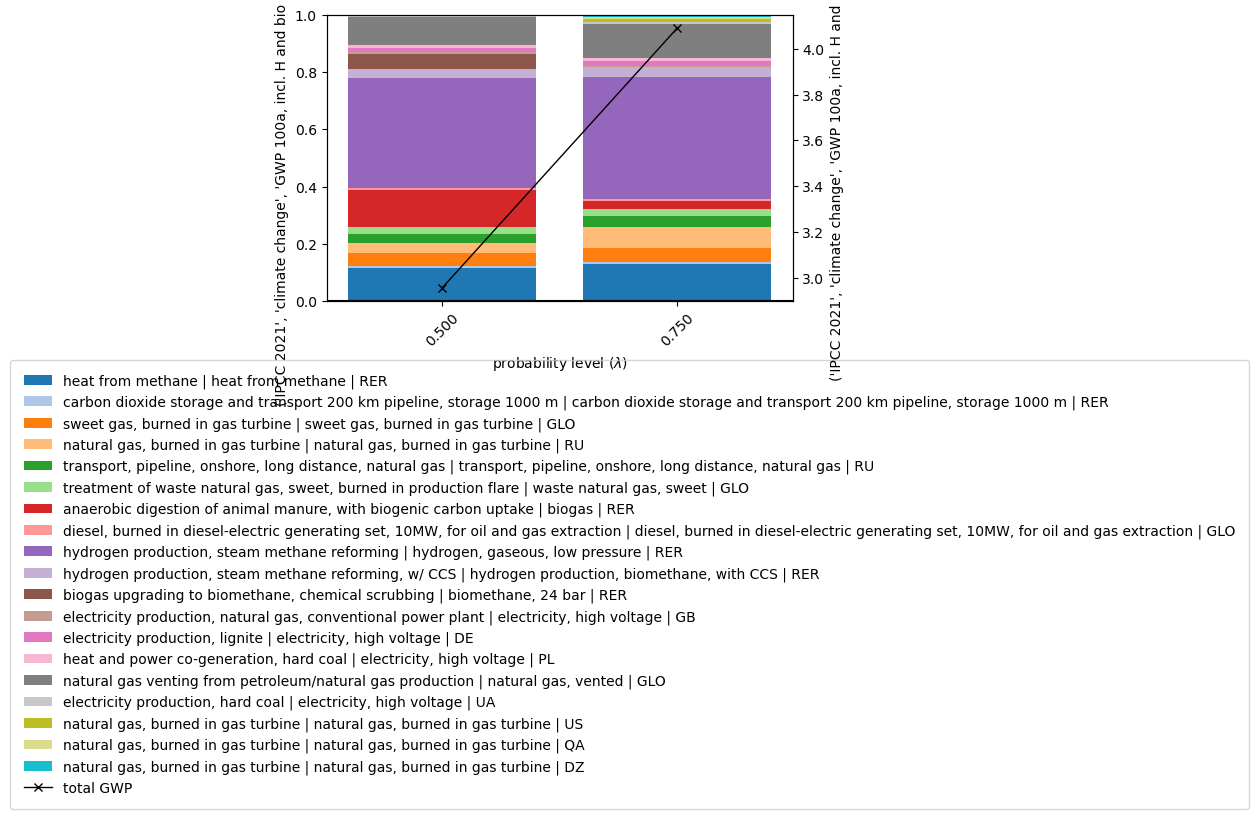

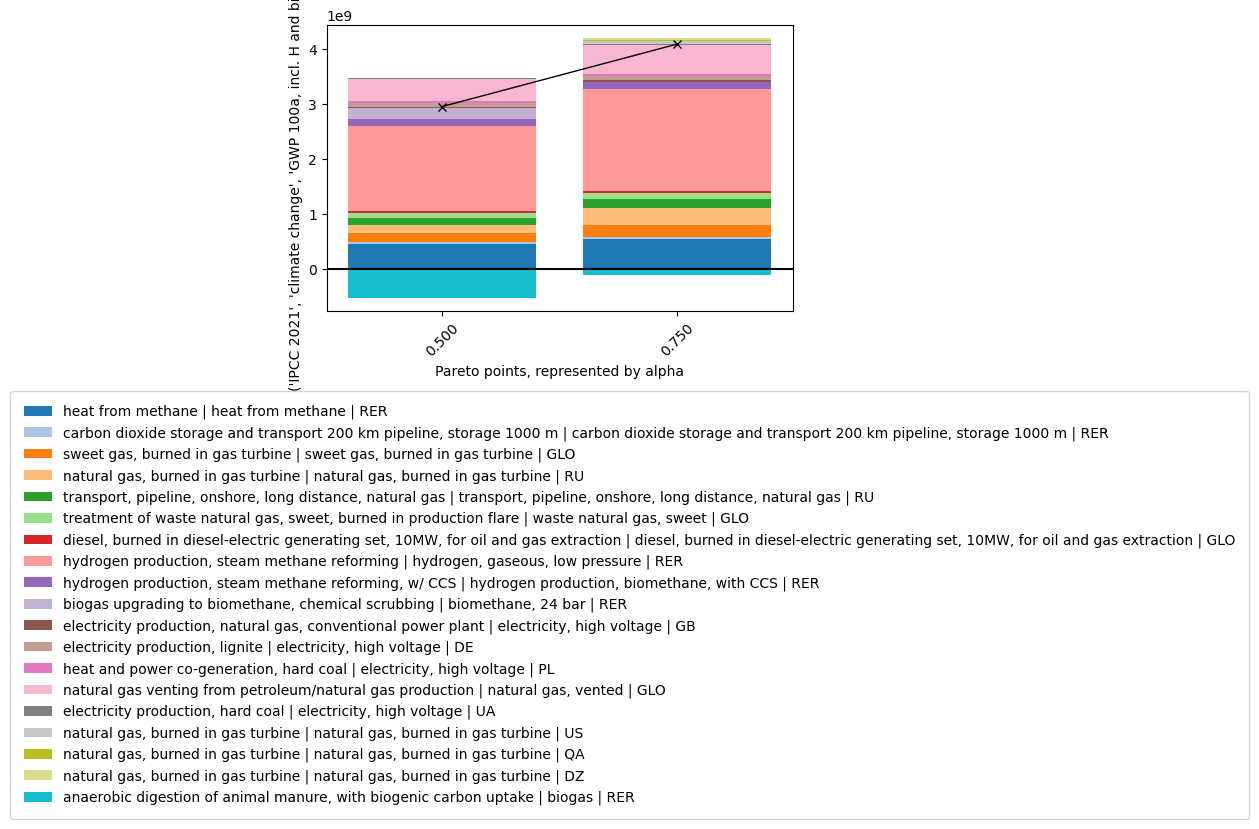

In [67]:
plots.plot_pareto_front(results_CC, 0.005, case_study.method, case_study.pulpo_worker.lci_data['process_map_metadata'], bbox_to_anchor=(0.65,-1.8))

Compare the Pareto points

In [71]:
saver.compare_subsequent_paretosolutions(results_CC, case_study.choices, case_study.method)

('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')
0.5: 3885267309.3785768
0.75: 5153539422.817212


'ammonia'

,Capacity,0.5,0.75
Metadata,,,
"ammonia production, from nitrogen and hydrogen | ammonia production, from nitrogen and hydrogen | RER",1.000000e+20,2.010086e+09,2.010081e+09
"ammonia production, steam methane reforming | ammonia production, biomethane | RER",1.000000e+20,-0.000000e+00,-0.000000e+00


'methane_market'

,Capacity,0.5,0.75
Metadata,,,
"market group for natural gas, high pressure | natural gas, high pressure | Europe without Switzerland",1.000000e+20,2.093503e+09,2.229354e+09
market for bio methane | methane | RER,1.000000e+20,2.108737e+08,6.921095e+07


...

'biomethane'

,Capacity,0.5,0.75
Metadata,,,
"biogas upgrading to biomethane, chemical scrubbing | biomethane, 24 bar | RER",1.000000e+20,1.368890e+08,-0.000000e+00
"biogas upgrading to biomethane, water scrubbing w/ CCS | biomethane, 24 bar | RER",3.600000e+07,3.620129e+07,3.435588e+07
"biogas upgrading to biomethane, chemical scrubbing w/ CCS | biomethane, 24 bar | RER",3.600000e+07,3.567463e+07,3.416296e+07
"biogas upgrading to biomethane, water scrubbing | biomethane, 24 bar | RER",1.000000e+20,-0.000000e+00,-0.000000e+00


lambda_1: 0.5
lambda_2: 0.75

Amount of process scaling variables that changed:
13889: >1% 
4287: >10%
50: >100%
9: >1000%

Amount of process characterized scaling variables (impacts per process) that changed:
3: >1% 
0: >10%
0: >100%
0: >1000%

8.98368e-02: is the maximum impact change in one process
2.05898e-01: is the total impact change

The relative change of the characterized scaling vector (s_lambda_1 - s_lambda_2)*QB_s / QBs:



ID
anaerobic digestion of animal manure, with biogenic carbon uptake | biogas | RER                                                             0.089837
biogas upgrading to biomethane, chemical scrubbing | biomethane, 24 bar | RER                                                                0.052820
hydrogen production, steam methane reforming | hydrogen, gaseous, low pressure | RER                                                         0.018348
natural gas venting from petroleum/natural gas production | natural gas, vented | GLO                                                        0.004957
softwood forestry, mixed species, sustainable forest management | sawlog and veneer log, softwood, measured as solid wood under bark | CH    0.002994
sweet gas, burned in gas turbine | sweet gas, burned in gas turbine | GLO                                                                    0.002339
hydrogen production, steam methane reforming, w/ CCS | hydrogen production, biomethane, with CCS 


---



Using the Pulpo worker

In [ ]:
lambda_epsilon_array = np.linspace(0.5,1, 2, endpoint=False)
results_CC = case_study.pulpo_worker.solve_CC_problem(lambda_epsilon_array, normal_metadata_env_cost, normal_metadata_var_bounds)

solving CC problem for lambda_QB = 0.5
Applying CC constraints to the environmental cost calculation with lambda: 0.5
Applying CC constraints to the upper_limit constraint with lambda: 0.5
Running HiGHS 1.8.0 (git hash: eda5cbe): Copyright (c) 2024 HiGHS under MIT licence terms
Cols:       47102 lower bounds    less than or equal to       -1e+20 are treated as -Infinity
Cols:       47102 upper bounds greater than or equal to        1e+20 are treated as +Infinity
Rows:       23537 lower bounds    less than or equal to       -1e+20 are treated as -Infinity
Rows:       23546 upper bounds greater than or equal to        1e+20 are treated as +Infinity
optimal solution found:  3885267309.3785768
solving CC problem for lambda_QB = 0.75
Applying CC constraints to the environmental cost calculation with lambda: 0.75
Applying CC constraints to the upper_limit constraint with lambda: 0.75
Running HiGHS 1.8.0 (git hash: eda5cbe): Copyright (c) 2024 HiGHS under MIT licence terms
Cols:       47102 l

{0.5: {'Scaling Vector':                                                      Key  \
  ID                                                         
  23536  (ammonia-reduced, 7f6425e34c57953608413402033f...   
  23539  (ammonia-reduced, c29eca25ce3f4456aa791def05b6...   
  23525  (ammonia-reduced, 28f072c14eb4c2cd3c7efef04c11...   
  23556  (ammonia-reduced, 7bdc8ab4c3ab9f8d8fccdf1b37cc...   
  23526  (ammonia-reduced, ac4d3ba99b4f4cfb9308ab1f4e6c...   
  ...                                                  ...   
  3709   (ecoinvent-3.10-cutoff, 7ee404e8eee08f5b2d8e51...   
  6258   (ecoinvent-3.10-cutoff, 4c0f2490c606e7e09c01c6...   
  3700   (ecoinvent-3.10-cutoff, c8b285bf1f33640398b677...   
  14142  (ecoinvent-3.10-cutoff, 5a63ce1ef701d4506e6259...   
  2585   (ecoinvent-3.10-cutoff, 647fd2e1bcf7ca63bacf2b...   
  
                                                  Metadata         Value  
  ID                                                                      
  23536           